In [1]:
import numpy as np
import torch
import torchvision.models
import torch.nn as nn
import pandas as pd
import time
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent.parent.parent))
from models.utils import set_seed, train, evaluate_model, plot_training_history, get_loaders
from models.baseline_cnn import BaselineCNN
from models.alexnet import ModifiedAlexNet

sys.path.append(str(Path().resolve().parent))
from hyperparameter_plots import summarize_results, print_summary_table, plot_loss_comparison, plot_accuracy_comparison
sys.path.append(str(Path().resolve().parent.parent))
from utils import save_results

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [2]:
DATA_DIR = Path("../../../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [3]:
DROPOUT = [0.0, 0.2, 0.3, 0.5, 0.7]
SEEDS = [0, 1, 2]
BATCH_SIZE = 256

In [4]:
def create_baseline_model(droput):
    model = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], 
                        kernel_sizes = [3, 3, 3], fc_layers = [128, 64], dropout=droput, num_classes = 10)
    return model

def create_resnet_model(dropout):
    model = torchvision.models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 10)
    )
    model = model.to(device)
    return model

def create_alexnet_model(dropout):
    model = ModifiedAlexNet(num_classes=10, droput=dropout).to(device)
    return model

def test_dropout_rate(model, train_loader, valid_loader, test_loader, dropouts,
        seeds, scheduler=None, device=None, num_epochs=20):
    
    results = {}
    for dr in dropouts:
        results[dr] = {}
        for seed in seeds:
            print(f"\nDROPOUT={dr} | SEED={seed}")
            set_seed(seed)

            model_instance = model(dr)
            criterion = torch.nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model_instance.parameters(), lr=1e-3)

            print("------------------------------------------------------")


            history = train(model_instance, train_loader, valid_loader, criterion, optimizer,
                scheduler=scheduler, device=device, num_epochs=num_epochs, verbose=True, verbose_interval=int(num_epochs/10))
            
            
            validation_accuracy = history['valid_acc'][-1]
            validation_loss = history['valid_loss'][-1]
            test_accuracy, test_loss = evaluate_model(model_instance, test_loader, criterion, device)

            results[dr][seed] = {
                "history": history,
                "valid_acc": validation_accuracy,
                "valid_loss": validation_loss,
                "test_acc": test_accuracy,
                "test_loss": test_loss
            }

            print("------------------------------------------------------")

            print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")

            print("------------------------------------------------------")

    return results

In [11]:
def analyze_results(results, model_name="Model"):

    rows = []
    for dr, seed_dict in results.items():
        for seed, values in seed_dict.items():
            history = values['history']
            rows.append({
                'dr':            dr,
                'seed':             seed,
                'test_acc':         values['test_acc'],
                'valid_acc':        values['valid_acc'],
                'train_loss_final': history['train_loss'][-1],
                'valid_loss_final': history['valid_loss'][-1],
            })
    df = pd.DataFrame(rows)

    stats = df.groupby('dr').agg(
        test_acc_mean  = ('test_acc', 'mean'),
        test_acc_std   = ('test_acc', 'std'),
        valid_acc_mean = ('valid_acc', 'mean'),
        train_loss_mean= ('train_loss_final', 'mean'),
        valid_loss_mean= ('valid_loss_final', 'mean'),
    ).sort_index()

    #Overfitting gap (val_loss - train_loss for the last epoch)
    stats['overfitting_gap'] = stats['valid_loss_mean'] - stats['train_loss_mean']

    #Coefficient of variation std/mean
    stats['cv'] = df.groupby('dr')['test_acc'].std() / df.groupby('dr')['test_acc'].mean()

    #Monotonicity check
    means = stats['test_acc_mean'].values
    is_monotonic = all(x <= y for x, y in zip(means, means[1:]))

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(stats[['test_acc_mean', 'test_acc_std', 'overfitting_gap', 'cv']].round(4))
    print(f"Monotonically increasing: {is_monotonic}")

    return stats

In [5]:
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

## Dropout experiments

#### Baseline model

In [6]:
baseline_results = test_dropout_rate(model=create_baseline_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, dropouts=DROPOUT, seeds=SEEDS, num_epochs=20, device=device)


DROPOUT=0.0 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.2618 | Valid Loss: 1.4892 | Valid Acc: 0.4800
Epoch 4/20 | Train Loss: 1.0681 | Valid Loss: 1.1893 | Valid Acc: 0.5669
Epoch 6/20 | Train Loss: 0.9440 | Valid Loss: 1.0356 | Valid Acc: 0.6272
Epoch 8/20 | Train Loss: 0.8423 | Valid Loss: 1.4551 | Valid Acc: 0.5399
Epoch 10/20 | Train Loss: 0.7518 | Valid Loss: 1.0098 | Valid Acc: 0.6501
Epoch 12/20 | Train Loss: 0.6691 | Valid Loss: 1.4202 | Valid Acc: 0.5610
Epoch 14/20 | Train Loss: 0.5809 | Valid Loss: 1.1287 | Valid Acc: 0.6315
Epoch 16/20 | Train Loss: 0.5008 | Valid Loss: 1.3598 | Valid Acc: 0.6030
Epoch 18/20 | Train Loss: 0.4279 | Valid Loss: 1.2636 | Valid Acc: 0.6436
Epoch 20/20 | Train Loss: 0.3522 | Valid Loss: 2.1005 | Valid Acc: 0.5476
Best validation accuracy: 0.6501
------------------------------------------------------
VALIDATION ACCURACY: 0.5476 | TEST ACCURACY: 0.5449
-----------------------------------------------

In [7]:
save_results(baseline_results, 'dropout_results_baseline.json')

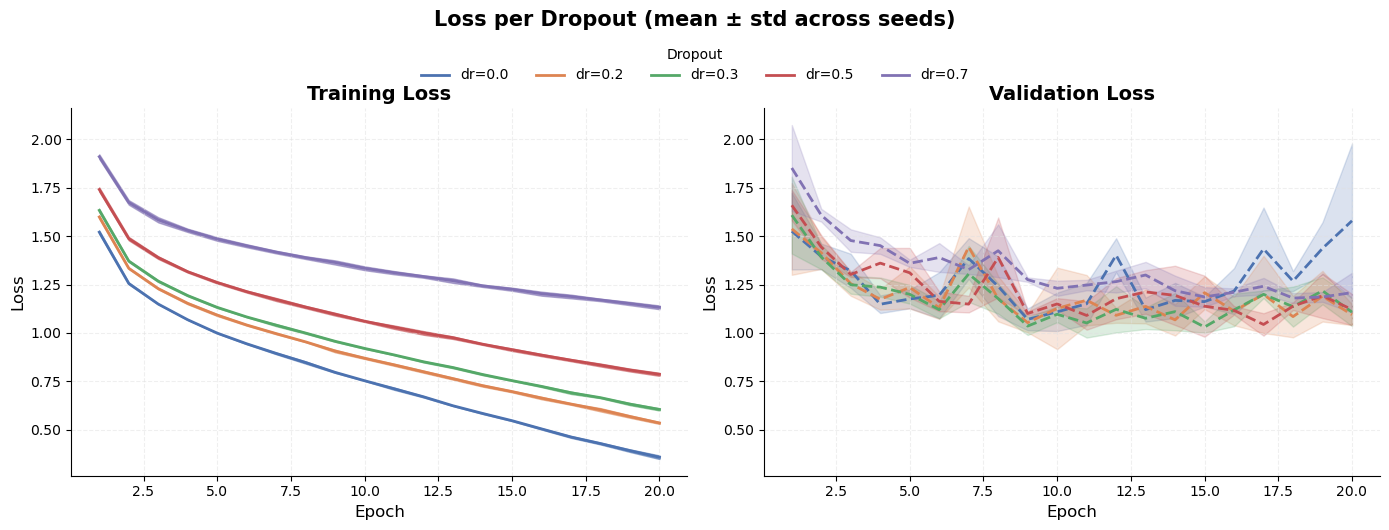

In [6]:
plot_loss_comparison(baseline_results, param_name="Dropout", param_name_short = 'dr')

In [43]:
df = summarize_results(baseline_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.0,0.607081,0.050102,1.579780,0.398951,0.605885,0.050891,1.595699,0.402124
1,Model,0.2,0.652100,0.009867,1.094331,0.053738,0.651578,0.010418,1.105276,0.057449
2,Model,0.3,0.640815,0.015189,1.107773,0.072132,0.639137,0.014593,1.120630,0.072446
3,Model,0.5,0.623933,0.024378,1.121158,0.080222,0.621700,0.023431,1.132468,0.081879
4,Model,0.7,0.553411,0.025812,1.208337,0.102613,0.550326,0.025232,1.217165,0.105291


In [45]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.0,0.6071 ± 0.0501,1.5798 ± 0.3990,0.6059 ± 0.0509,1.5957 ± 0.4021
1,Model,0.2,0.6521 ± 0.0099,1.0943 ± 0.0537,0.6516 ± 0.0104,1.1053 ± 0.0574
2,Model,0.3,0.6408 ± 0.0152,1.1078 ± 0.0721,0.6391 ± 0.0146,1.1206 ± 0.0724
3,Model,0.5,0.6239 ± 0.0244,1.1212 ± 0.0802,0.6217 ± 0.0234,1.1325 ± 0.0819
4,Model,0.7,0.5534 ± 0.0258,1.2083 ± 0.1026,0.5503 ± 0.0252,1.2172 ± 0.1053


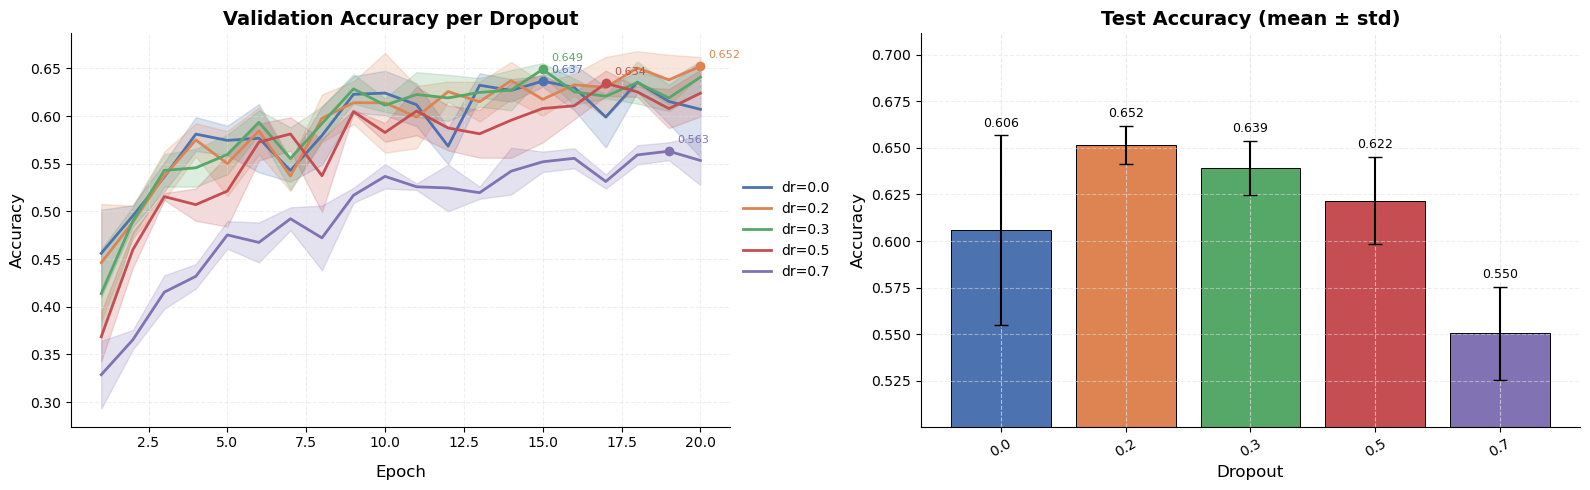

In [7]:
plot_accuracy_comparison(baseline_results, param_name='Dropout', param_name_short='dr')

In [12]:
stats = analyze_results(baseline_results, model_name='BaselineCNN')


  BaselineCNN
     test_acc_mean  test_acc_std  overfitting_gap      cv
dr                                                       
0.0         0.6059        0.0623           1.2223  0.1029
0.2         0.6516        0.0128           0.5597  0.0196
0.3         0.6391        0.0179           0.5032  0.0280
0.5         0.6217        0.0287           0.3351  0.0462
0.7         0.5503        0.0309           0.0760  0.0562
Monotonically increasing: False


#### Alexnet

In [9]:
alexnet_results_dropout = test_dropout_rate(model=create_alexnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, dropouts=DROPOUT, seeds=SEEDS, num_epochs=20, device=device)


DROPOUT=0.0 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.1474 | Valid Loss: 1.1984 | Valid Acc: 0.5711
Epoch 4/20 | Train Loss: 0.8805 | Valid Loss: 1.0203 | Valid Acc: 0.6361
Epoch 6/20 | Train Loss: 0.7120 | Valid Loss: 0.9391 | Valid Acc: 0.6699
Epoch 8/20 | Train Loss: 0.5554 | Valid Loss: 0.9267 | Valid Acc: 0.6928
Epoch 10/20 | Train Loss: 0.4083 | Valid Loss: 0.9608 | Valid Acc: 0.7098
Epoch 12/20 | Train Loss: 0.2737 | Valid Loss: 1.1945 | Valid Acc: 0.6966
Epoch 14/20 | Train Loss: 0.1713 | Valid Loss: 1.2888 | Valid Acc: 0.6987
Epoch 16/20 | Train Loss: 0.1256 | Valid Loss: 1.5548 | Valid Acc: 0.7001
Epoch 18/20 | Train Loss: 0.0859 | Valid Loss: 1.6737 | Valid Acc: 0.6957
Epoch 20/20 | Train Loss: 0.0777 | Valid Loss: 1.7203 | Valid Acc: 0.7163
Best validation accuracy: 0.7195
------------------------------------------------------
VALIDATION ACCURACY: 0.7163 | TEST ACCURACY: 0.7125
-----------------------------------------------

In [10]:
save_results(alexnet_results_dropout, 'dropout_results_alexnet.json')

In [ ]:
plot_loss_comparison(alexnet_results_dropout, param_name="Dropout", param_name_short = 'dr')
df = summarize_results(alexnet_results_dropout)
df
print_summary_table(df, hyperparameter='lr')
plot_accuracy_comparison(alexnet_results_dropout, param_name='Dropout', param_name_short='dr')

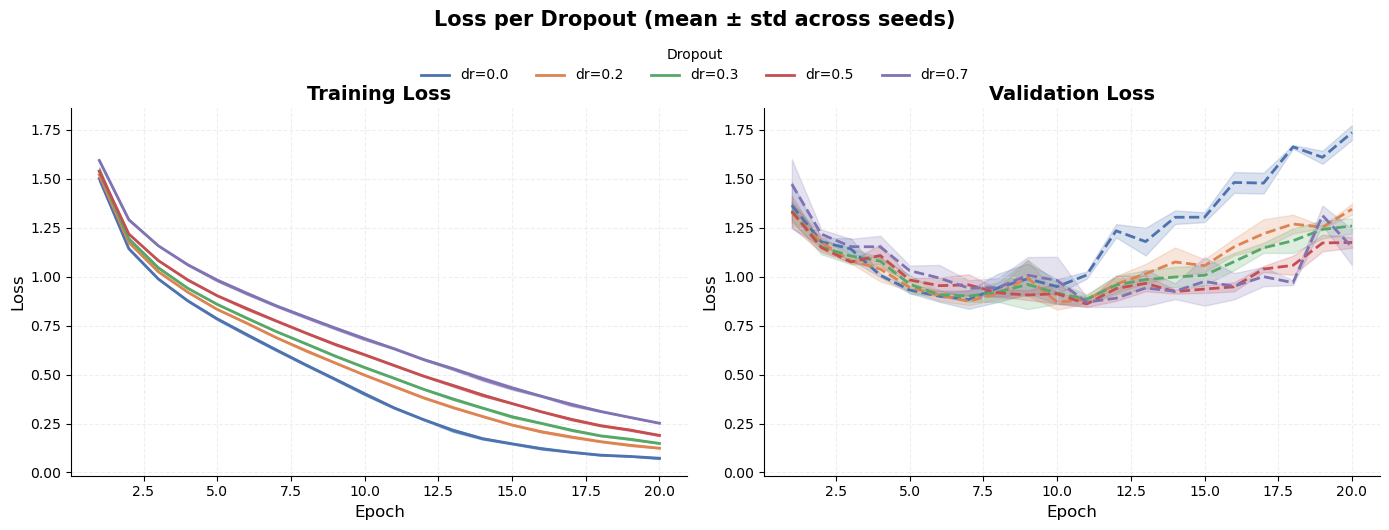

In [15]:
plot_loss_comparison(alexnet_results_dropout, param_name="Dropout", param_name_short = 'dr')

In [48]:
df = summarize_results(alexnet_results_dropout)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.0,0.709596,0.005083,1.735189,0.038194,0.706593,0.004445,1.767115,0.029811
1,Model,0.2,0.724011,0.002361,1.343986,0.028406,0.721941,0.002329,1.361399,0.025769
2,Model,0.3,0.723433,0.004767,1.258093,0.038987,0.721952,0.005302,1.273313,0.042116
3,Model,0.5,0.717526,0.011017,1.174095,0.027310,0.716563,0.011439,1.185701,0.027313
4,Model,0.7,0.704830,0.008758,1.149952,0.092806,0.702304,0.009471,1.163717,0.093485


In [49]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.0,0.7096 ± 0.0051,1.7352 ± 0.0382,0.7066 ± 0.0044,1.7671 ± 0.0298
1,Model,0.2,0.7240 ± 0.0024,1.3440 ± 0.0284,0.7219 ± 0.0023,1.3614 ± 0.0258
2,Model,0.3,0.7234 ± 0.0048,1.2581 ± 0.0390,0.7220 ± 0.0053,1.2733 ± 0.0421
3,Model,0.5,0.7175 ± 0.0110,1.1741 ± 0.0273,0.7166 ± 0.0114,1.1857 ± 0.0273
4,Model,0.7,0.7048 ± 0.0088,1.1500 ± 0.0928,0.7023 ± 0.0095,1.1637 ± 0.0935


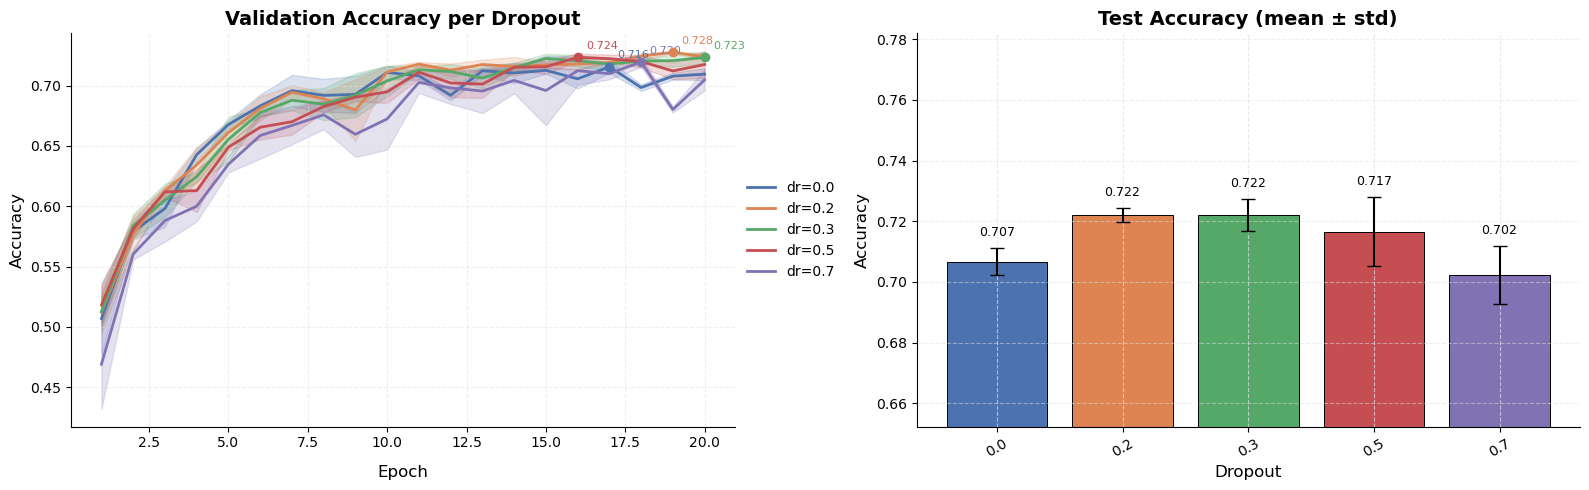

In [14]:
plot_accuracy_comparison(alexnet_results_dropout, param_name='Dropout', param_name_short='dr')

In [16]:
stats = analyze_results(alexnet_results_dropout, model_name='AlexNet')


  AlexNet
     test_acc_mean  test_acc_std  overfitting_gap      cv
dr                                                       
0.0         0.7066        0.0054           1.6624  0.0077
0.2         0.7219        0.0029           1.2200  0.0040
0.3         0.7220        0.0065           1.1097  0.0090
0.5         0.7166        0.0140           0.9848  0.0196
0.7         0.7023        0.0116           0.8984  0.0165
Monotonically increasing: False


#### Resnet

In [17]:
resnet_results_dropout = test_dropout_rate(model=create_resnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, dropouts=DROPOUT, seeds=SEEDS, num_epochs=20, device=device)


DROPOUT=0.0 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.2365 | Valid Loss: 1.2239 | Valid Acc: 0.5614
Epoch 4/20 | Train Loss: 0.9961 | Valid Loss: 1.1279 | Valid Acc: 0.5938
Epoch 6/20 | Train Loss: 0.8088 | Valid Loss: 1.1664 | Valid Acc: 0.5928
Epoch 8/20 | Train Loss: 0.6194 | Valid Loss: 1.1682 | Valid Acc: 0.6244
Epoch 10/20 | Train Loss: 0.4283 | Valid Loss: 1.3566 | Valid Acc: 0.6167
Epoch 12/20 | Train Loss: 0.2784 | Valid Loss: 1.5935 | Valid Acc: 0.6194
Epoch 14/20 | Train Loss: 0.1933 | Valid Loss: 1.7870 | Valid Acc: 0.6115
Epoch 16/20 | Train Loss: 0.1419 | Valid Loss: 2.0353 | Valid Acc: 0.6095
Epoch 18/20 | Train Loss: 0.1180 | Valid Loss: 2.0806 | Valid Acc: 0.6134
Epoch 20/20 | Train Loss: 0.1028 | Valid Loss: 2.2156 | Valid Acc: 0.6106
Best validation accuracy: 0.6244
------------------------------------------------------
VALIDATION ACCURACY: 0.6106 | TEST ACCURACY: 0.6095
-----------------------------------------------

In [18]:
save_results(resnet_results_dropout, 'dropout_results_resnet.json')

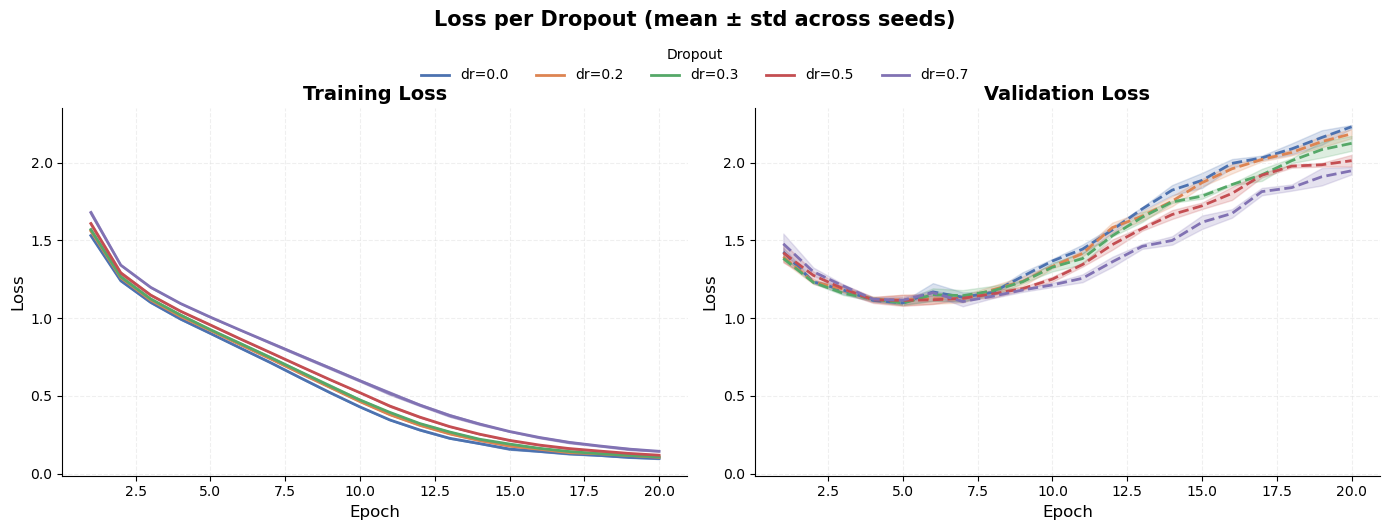

In [20]:
plot_loss_comparison(resnet_results_dropout, param_name="Dropout", param_name_short = 'dr')

In [52]:
df = summarize_results(resnet_results_dropout)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.0,0.610470,0.000152,2.231420,0.011308,0.609874,0.000777,2.242389,0.012255
1,Model,0.2,0.613922,0.001790,2.186257,0.028476,0.613544,0.002272,2.197141,0.016277
2,Model,0.3,0.614519,0.000700,2.125046,0.048013,0.614544,0.000135,2.134963,0.041827
3,Model,0.5,0.609926,0.002299,2.013492,0.037747,0.609807,0.002382,2.029154,0.039399
4,Model,0.7,0.613152,0.001608,1.948568,0.023630,0.612385,0.000356,1.959436,0.025999


In [53]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.0,0.6105 ± 0.0002,2.2314 ± 0.0113,0.6099 ± 0.0008,2.2424 ± 0.0123
1,Model,0.2,0.6139 ± 0.0018,2.1863 ± 0.0285,0.6135 ± 0.0023,2.1971 ± 0.0163
2,Model,0.3,0.6145 ± 0.0007,2.1250 ± 0.0480,0.6145 ± 0.0001,2.1350 ± 0.0418
3,Model,0.5,0.6099 ± 0.0023,2.0135 ± 0.0377,0.6098 ± 0.0024,2.0292 ± 0.0394
4,Model,0.7,0.6132 ± 0.0016,1.9486 ± 0.0236,0.6124 ± 0.0004,1.9594 ± 0.0260


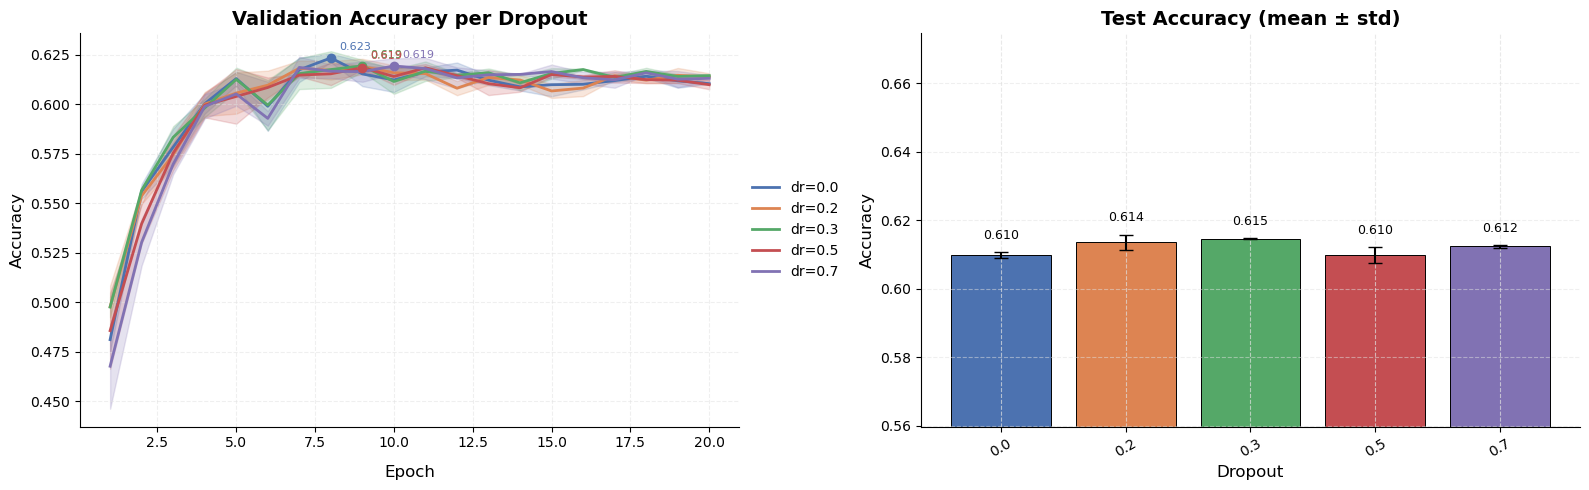

In [21]:
plot_accuracy_comparison(resnet_results_dropout, param_name='Dropout', param_name_short='dr')

In [22]:
stats = analyze_results(resnet_results_dropout, model_name='ResNet')


  ResNet
     test_acc_mean  test_acc_std  overfitting_gap      cv
dr                                                       
0.0         0.6099        0.0010           2.1336  0.0016
0.2         0.6135        0.0028           2.0812  0.0045
0.3         0.6145        0.0002           2.0171  0.0003
0.5         0.6098        0.0029           1.8946  0.0048
0.7         0.6124        0.0004           1.8045  0.0007
Monotonically increasing: False


## Weight decay

In [27]:
def create_baseline_model():
    model = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], 
                        kernel_sizes = [3, 3, 3], fc_layers = [128, 64], num_classes = 10)
    return model

def create_resnet_model():
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)
    return model

def create_alexnet_model():
    model = ModifiedAlexNet(num_classes=10).to(device)
    return model

def test_weight_decay(model, train_loader, valid_loader, test_loader, weight_decays, seeds, scheduler=None, device=None, num_epochs=20):

    results = {}

    for wd in weight_decays:
        results[wd] = {}

        for seed in seeds:
            print(f"\nWEIGHT_DECAY={wd} | SEED={seed}")
            set_seed(seed)

            model_instance = model()
            model_instance = model_instance.to(device)

            criterion = torch.nn.CrossEntropyLoss()

            optimizer = torch.optim.AdamW(model_instance.parameters(), lr=1e-3, weight_decay=wd)

            print("------------------------------------------------------")

            history = train(
                model_instance,
                train_loader,
                valid_loader,
                criterion,
                optimizer,
                scheduler=scheduler,
                device=device,
                num_epochs=num_epochs,
                verbose=True,
                verbose_interval=max(1, int(num_epochs/10))
            )

            validation_accuracy = history['valid_acc'][-1]
            validation_loss = history['valid_loss'][-1]

            test_accuracy, test_loss = evaluate_model(
                model_instance, test_loader, criterion, device
            )

            results[wd][seed] = {
                "history": history,
                "valid_acc": validation_accuracy,
                "valid_loss": validation_loss,
                "test_acc": test_accuracy,
                "test_loss": test_loss
            }

            print("------------------------------------------------------")
            print(f"VALID ACC: {validation_accuracy:.4f} | TEST ACC: {test_accuracy:.4f}")
            print("------------------------------------------------------")

    return results

In [29]:
WEIGHT_DECAYS = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]
SEEDS = [0, 1, 2]
BATCH_SIZE = 256

#### Baseline model

In [30]:
baseline_results_weight_decay = test_weight_decay(model=create_baseline_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, weight_decays=WEIGHT_DECAYS, seeds=SEEDS, num_epochs=20, device=device)


WEIGHT_DECAY=0.0 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.2618 | Valid Loss: 1.4892 | Valid Acc: 0.4800
Epoch 4/20 | Train Loss: 1.0681 | Valid Loss: 1.1893 | Valid Acc: 0.5669
Epoch 6/20 | Train Loss: 0.9440 | Valid Loss: 1.0356 | Valid Acc: 0.6272
Epoch 8/20 | Train Loss: 0.8423 | Valid Loss: 1.4551 | Valid Acc: 0.5399
Epoch 10/20 | Train Loss: 0.7518 | Valid Loss: 1.0098 | Valid Acc: 0.6501
Epoch 12/20 | Train Loss: 0.6691 | Valid Loss: 1.4202 | Valid Acc: 0.5610
Epoch 14/20 | Train Loss: 0.5809 | Valid Loss: 1.1287 | Valid Acc: 0.6315
Epoch 16/20 | Train Loss: 0.5008 | Valid Loss: 1.3598 | Valid Acc: 0.6030
Epoch 18/20 | Train Loss: 0.4279 | Valid Loss: 1.2636 | Valid Acc: 0.6436
Epoch 20/20 | Train Loss: 0.3522 | Valid Loss: 2.1005 | Valid Acc: 0.5476
Best validation accuracy: 0.6501
------------------------------------------------------
VALID ACC: 0.5476 | TEST ACC: 0.5449
------------------------------------------------------

W

In [37]:
save_results(baseline_results_weight_decay, 'L2_results_baseline.json')

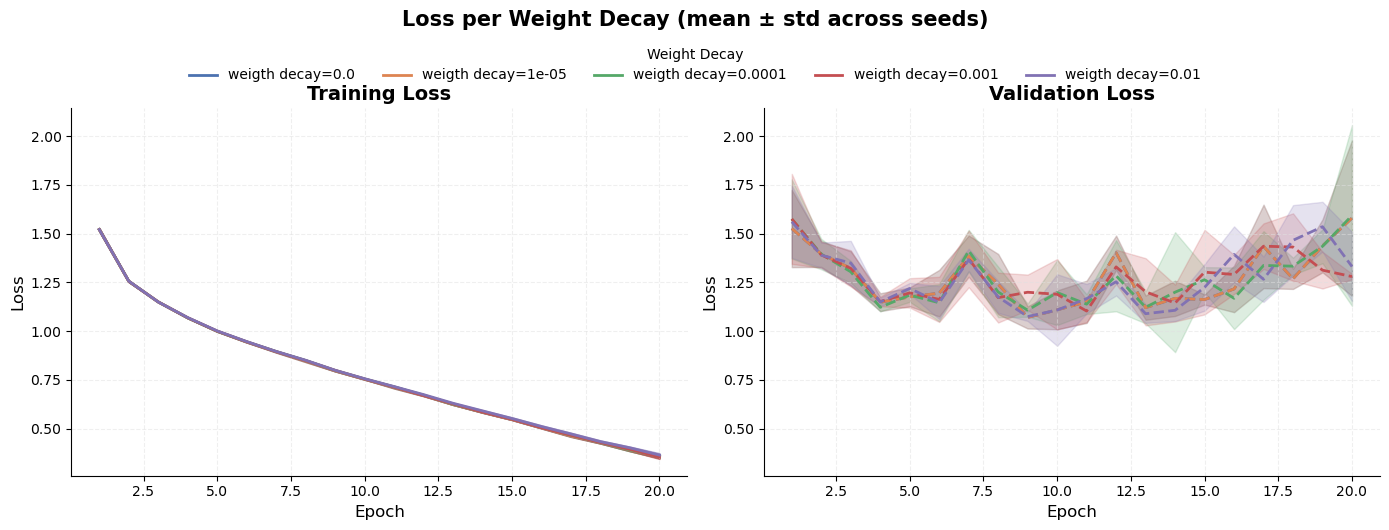

In [36]:
plot_loss_comparison(baseline_results_weight_decay, param_name="Weight Decay", param_name_short = 'weigth decay')

In [57]:
df = summarize_results(baseline_results_weight_decay)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.00000,0.607081,0.050102,1.579780,0.398951,0.605885,0.050891,1.595699,0.402124
1,Model,0.00001,0.607081,0.050102,1.579780,0.398951,0.605885,0.050891,1.595699,0.402124
2,Model,0.00010,0.607074,0.051984,1.592845,0.463612,0.605363,0.051769,1.613849,0.467655
3,Model,0.00100,0.646226,0.009964,1.279743,0.014007,0.644819,0.010526,1.295594,0.017306
4,Model,0.01000,0.631770,0.025902,1.331103,0.177509,0.630126,0.025626,1.351021,0.181140


In [58]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.00000,0.6071 ± 0.0501,1.5798 ± 0.3990,0.6059 ± 0.0509,1.5957 ± 0.4021
1,Model,0.00001,0.6071 ± 0.0501,1.5798 ± 0.3990,0.6059 ± 0.0509,1.5957 ± 0.4021
2,Model,0.00010,0.6071 ± 0.0520,1.5928 ± 0.4636,0.6054 ± 0.0518,1.6138 ± 0.4677
3,Model,0.00100,0.6462 ± 0.0100,1.2797 ± 0.0140,0.6448 ± 0.0105,1.2956 ± 0.0173
4,Model,0.01000,0.6318 ± 0.0259,1.3311 ± 0.1775,0.6301 ± 0.0256,1.3510 ± 0.1811


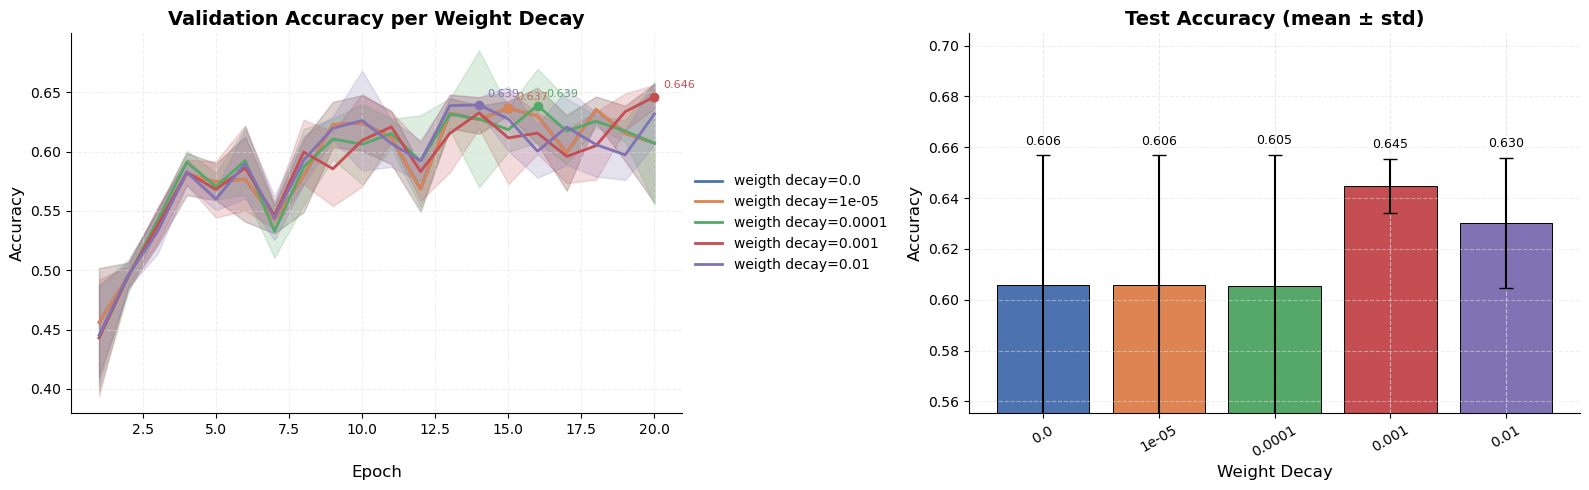

In [37]:
plot_accuracy_comparison(baseline_results_weight_decay, param_name="Weight Decay", param_name_short = 'weigth decay')

In [27]:
stats = analyze_results(baseline_results_weight_decay, 'Baseline CNN')


  Baseline CNN
         test_acc_mean  test_acc_std  overfitting_gap      cv
dr                                                           
0.00000         0.6059        0.0623           1.2223  0.1029
0.00001         0.6059        0.0623           1.2223  0.1029
0.00010         0.6054        0.0634           1.2339  0.1047
0.00100         0.6448        0.0129           0.9241  0.0200
0.01000         0.6301        0.0314           0.9665  0.0498
Monotonically increasing: False


#### Alexnet

In [32]:
alexnet_results_weight_decay = test_weight_decay(model=create_alexnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, weight_decays=WEIGHT_DECAYS, seeds=SEEDS, num_epochs=20, device=device)


WEIGHT_DECAY=0.0 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.2191 | Valid Loss: 1.1159 | Valid Acc: 0.5903
Epoch 4/20 | Train Loss: 0.9799 | Valid Loss: 1.0318 | Valid Acc: 0.6376
Epoch 6/20 | Train Loss: 0.8387 | Valid Loss: 0.9917 | Valid Acc: 0.6567
Epoch 8/20 | Train Loss: 0.7162 | Valid Loss: 0.9015 | Valid Acc: 0.6813
Epoch 10/20 | Train Loss: 0.6052 | Valid Loss: 0.9634 | Valid Acc: 0.6867
Epoch 12/20 | Train Loss: 0.4950 | Valid Loss: 0.8490 | Valid Acc: 0.7186
Epoch 14/20 | Train Loss: 0.4019 | Valid Loss: 0.9121 | Valid Acc: 0.7149
Epoch 16/20 | Train Loss: 0.3122 | Valid Loss: 0.9330 | Valid Acc: 0.7269
Epoch 18/20 | Train Loss: 0.2431 | Valid Loss: 1.0513 | Valid Acc: 0.7139
Epoch 20/20 | Train Loss: 0.1928 | Valid Loss: 1.1871 | Valid Acc: 0.7268
Best validation accuracy: 0.7269
------------------------------------------------------
VALID ACC: 0.7268 | TEST ACC: 0.7259
------------------------------------------------------

W

In [36]:
save_results(alexnet_results_weight_decay, 'L2_results_alexnet.json')

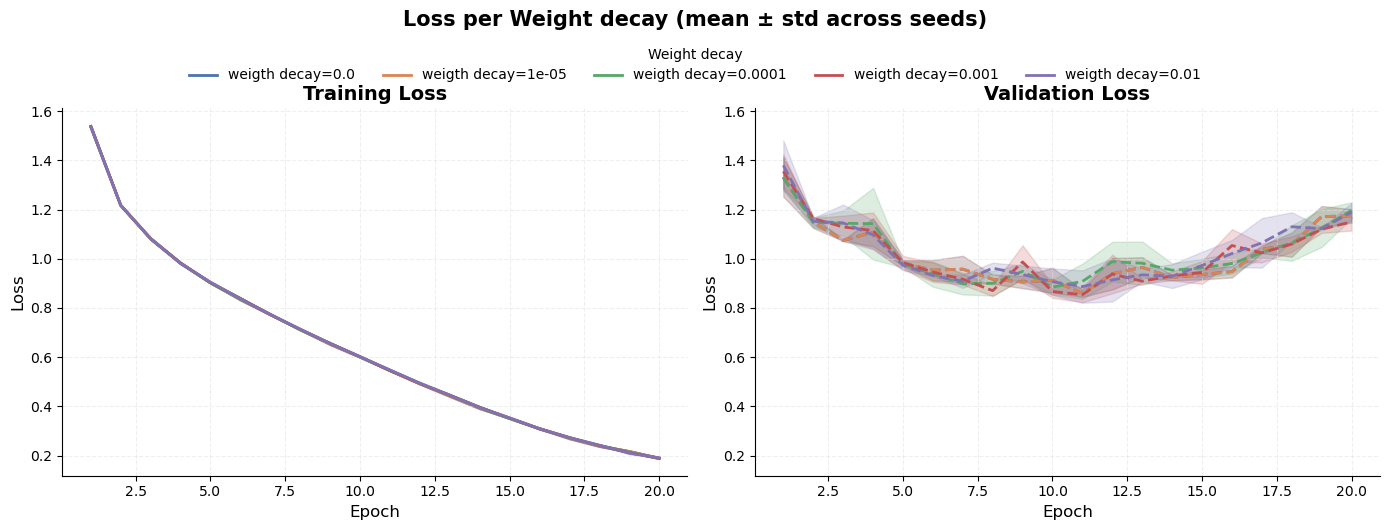

In [38]:
plot_loss_comparison(alexnet_results_weight_decay, param_name="Weight decay", param_name_short = 'weigth decay')

In [61]:
df = summarize_results(alexnet_results_weight_decay)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.00000,0.717526,0.011017,1.174095,0.027310,0.716563,0.011439,1.185701,0.027313
1,Model,0.00001,0.717526,0.011017,1.174095,0.027310,0.716563,0.011439,1.185701,0.027313
2,Model,0.00010,0.713963,0.002215,1.196532,0.033032,0.710519,0.000905,1.215894,0.032338
3,Model,0.00100,0.717511,0.002382,1.149878,0.035314,0.714504,0.001784,1.171295,0.032591
4,Model,0.01000,0.717011,0.005438,1.189627,0.036912,0.715200,0.004787,1.200137,0.038036


In [62]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.00000,0.7175 ± 0.0110,1.1741 ± 0.0273,0.7166 ± 0.0114,1.1857 ± 0.0273
1,Model,0.00001,0.7175 ± 0.0110,1.1741 ± 0.0273,0.7166 ± 0.0114,1.1857 ± 0.0273
2,Model,0.00010,0.7140 ± 0.0022,1.1965 ± 0.0330,0.7105 ± 0.0009,1.2159 ± 0.0323
3,Model,0.00100,0.7175 ± 0.0024,1.1499 ± 0.0353,0.7145 ± 0.0018,1.1713 ± 0.0326
4,Model,0.01000,0.7170 ± 0.0054,1.1896 ± 0.0369,0.7152 ± 0.0048,1.2001 ± 0.0380


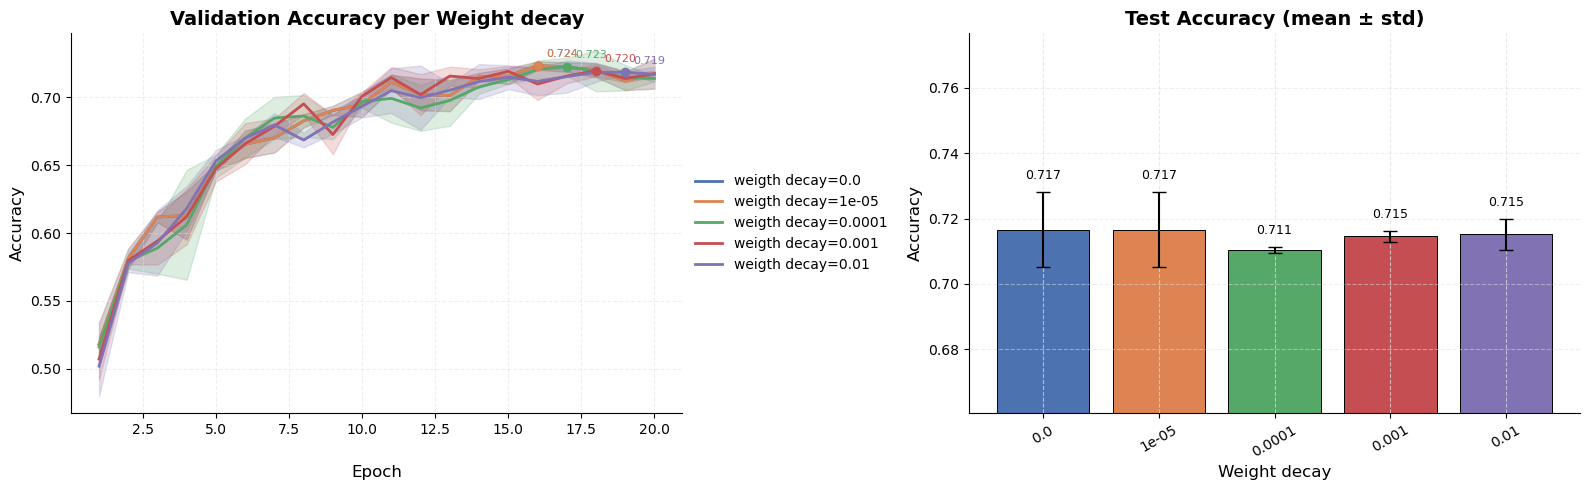

In [39]:
plot_accuracy_comparison(alexnet_results_weight_decay, param_name="Weight decay", param_name_short = 'weigth decay')

In [31]:
stats = analyze_results(alexnet_results_weight_decay, model_name="AlexNet")


  AlexNet
         test_acc_mean  test_acc_std  overfitting_gap      cv
dr                                                           
0.00000         0.7166        0.0140           0.9848  0.0196
0.00001         0.7166        0.0140           0.9848  0.0196
0.00010         0.7105        0.0011           1.0079  0.0016
0.00100         0.7145        0.0022           0.9601  0.0031
0.01000         0.7152        0.0059           0.9985  0.0082
Monotonically increasing: False


#### Resnet

In [34]:
resnet_results_weight_decay = test_weight_decay(model=create_resnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, weight_decays=WEIGHT_DECAYS, seeds=SEEDS, num_epochs=20, device=device)


WEIGHT_DECAY=0.0 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.2365 | Valid Loss: 1.2239 | Valid Acc: 0.5614
Epoch 4/20 | Train Loss: 0.9961 | Valid Loss: 1.1279 | Valid Acc: 0.5938
Epoch 6/20 | Train Loss: 0.8088 | Valid Loss: 1.1664 | Valid Acc: 0.5928
Epoch 8/20 | Train Loss: 0.6194 | Valid Loss: 1.1682 | Valid Acc: 0.6244
Epoch 10/20 | Train Loss: 0.4283 | Valid Loss: 1.3566 | Valid Acc: 0.6167
Epoch 12/20 | Train Loss: 0.2784 | Valid Loss: 1.5935 | Valid Acc: 0.6194
Epoch 14/20 | Train Loss: 0.1933 | Valid Loss: 1.7870 | Valid Acc: 0.6115
Epoch 16/20 | Train Loss: 0.1419 | Valid Loss: 2.0353 | Valid Acc: 0.6095
Epoch 18/20 | Train Loss: 0.1180 | Valid Loss: 2.0806 | Valid Acc: 0.6134
Epoch 20/20 | Train Loss: 0.1028 | Valid Loss: 2.2156 | Valid Acc: 0.6106
Best validation accuracy: 0.6244
------------------------------------------------------
VALID ACC: 0.6106 | TEST ACC: 0.6095
------------------------------------------------------

W

In [35]:
save_results(resnet_results_weight_decay, 'L2_results_resnet.json')

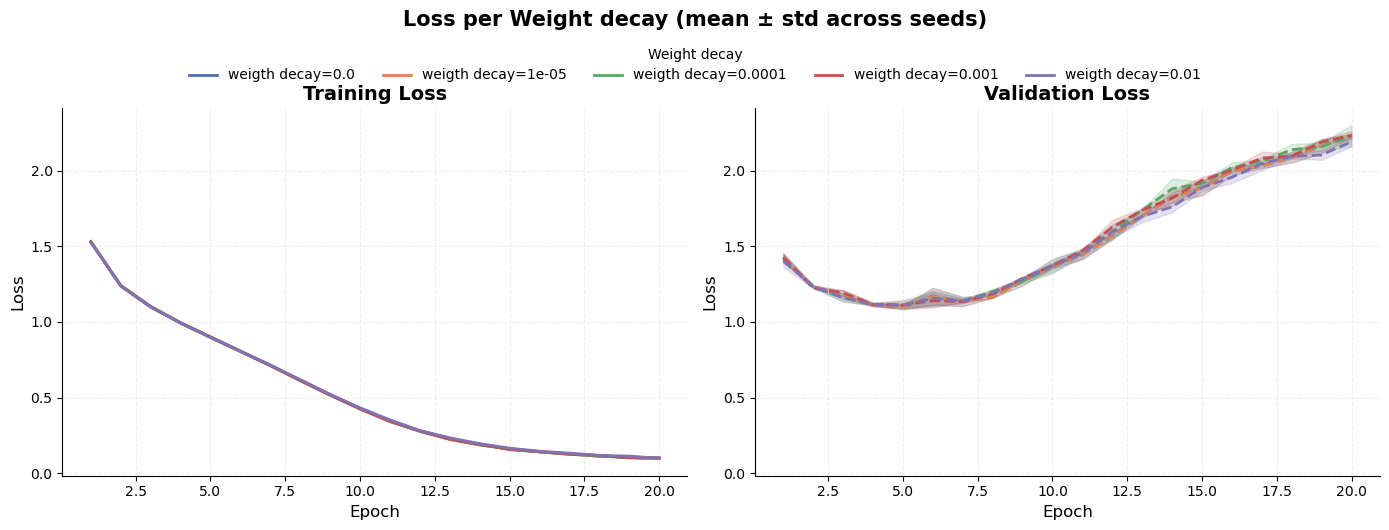

In [40]:
plot_loss_comparison(resnet_results_weight_decay, param_name="Weight decay", param_name_short = 'weigth decay')

In [65]:
df = summarize_results(resnet_results_weight_decay)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.00000,0.610470,0.000152,2.231420,0.011308,0.609874,0.000777,2.242389,0.012255
1,Model,0.00001,0.610470,0.000152,2.231420,0.011308,0.609874,0.000777,2.242389,0.012255
2,Model,0.00010,0.611559,0.001684,2.231263,0.070315,0.611563,0.002641,2.233849,0.082825
3,Model,0.00100,0.606993,0.006031,2.234046,0.028536,0.607381,0.008214,2.237618,0.036629
4,Model,0.01000,0.609181,0.002449,2.191984,0.030940,0.609959,0.001669,2.200565,0.019695


In [66]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.00000,0.6105 ± 0.0002,2.2314 ± 0.0113,0.6099 ± 0.0008,2.2424 ± 0.0123
1,Model,0.00001,0.6105 ± 0.0002,2.2314 ± 0.0113,0.6099 ± 0.0008,2.2424 ± 0.0123
2,Model,0.00010,0.6116 ± 0.0017,2.2313 ± 0.0703,0.6116 ± 0.0026,2.2338 ± 0.0828
3,Model,0.00100,0.6070 ± 0.0060,2.2340 ± 0.0285,0.6074 ± 0.0082,2.2376 ± 0.0366
4,Model,0.01000,0.6092 ± 0.0024,2.1920 ± 0.0309,0.6100 ± 0.0017,2.2006 ± 0.0197


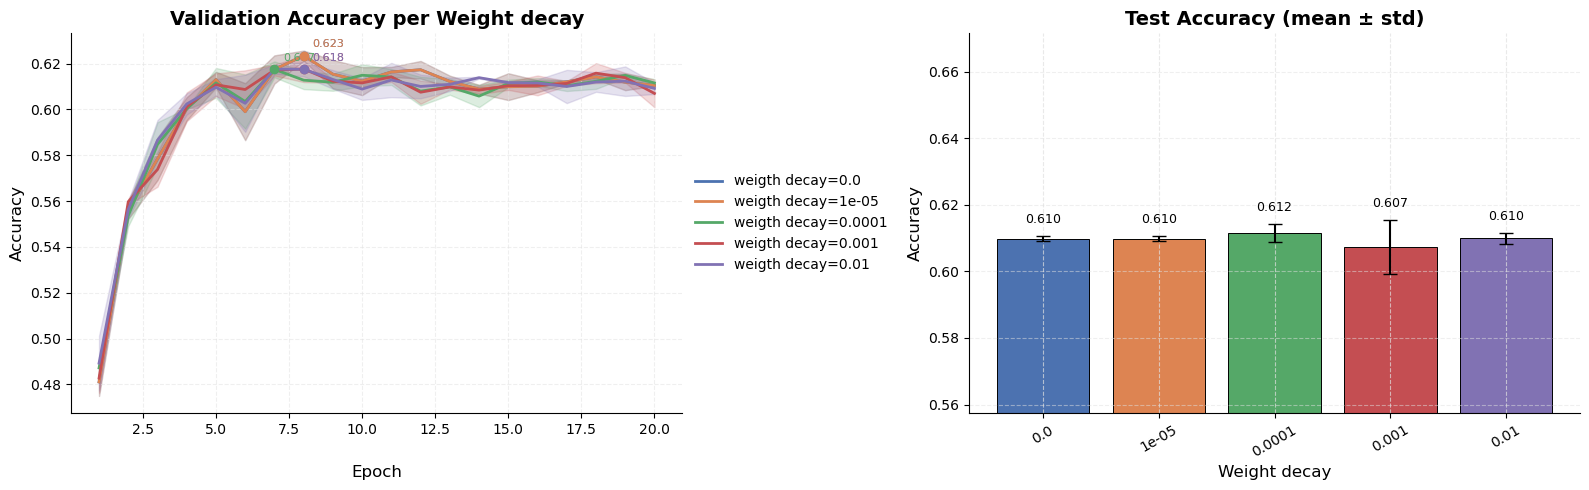

In [41]:
plot_accuracy_comparison(resnet_results_weight_decay, param_name="Weight decay", param_name_short = 'weigth decay')

In [35]:
stats = analyze_results(resnet_results_weight_decay, model_name="ResNet")


  ResNet
         test_acc_mean  test_acc_std  overfitting_gap      cv
dr                                                           
0.00000         0.6099        0.0010           2.1336  0.0016
0.00001         0.6099        0.0010           2.1336  0.0016
0.00010         0.6116        0.0032           2.1308  0.0053
0.00100         0.6074        0.0101           2.1311  0.0166
0.01000         0.6100        0.0020           2.0927  0.0034
Monotonically increasing: False
